In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import os
from sklearn.neighbors import KNeighborsClassifier
from scipy.cluster.hierarchy import linkage
import networkx as nx

sns.set(font_scale = 1.7)
palette = sns.color_palette("vlag", n_colors=100)
palette.reverse()
description = 'Interaction Network'


In [14]:
uc = pd.read_csv('uc_abs_thre_expression_28_genes.csv',delimiter=',').drop(columns=['cell_ID'])
bm = pd.read_csv('bm_abs_thre_expression_28_genes.csv',delimiter=',').drop(columns=['cell_ID'])
print(all(uc.columns == bm.columns))
ucint = np.corrcoef(uc.T)
bmint = np.corrcoef(bm.T)
fet = uc.columns

True


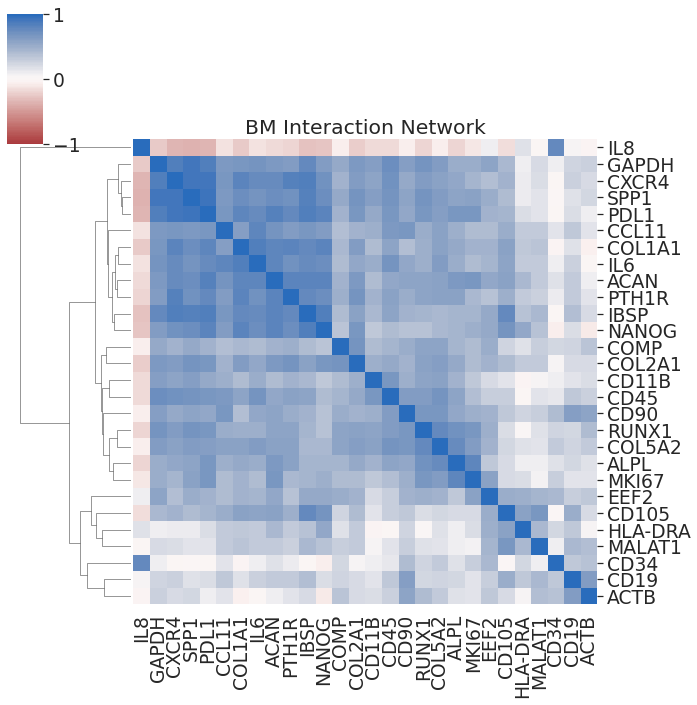

In [15]:
ax = sns.clustermap(bmint, vmin=-1, vmax=1, cmap=palette, xticklabels=fet, yticklabels=fet)
ax.ax_heatmap.set_title('BM '+description)
ax.ax_col_dendrogram.set_visible(False)
ax.savefig("BMinteractions.png") 

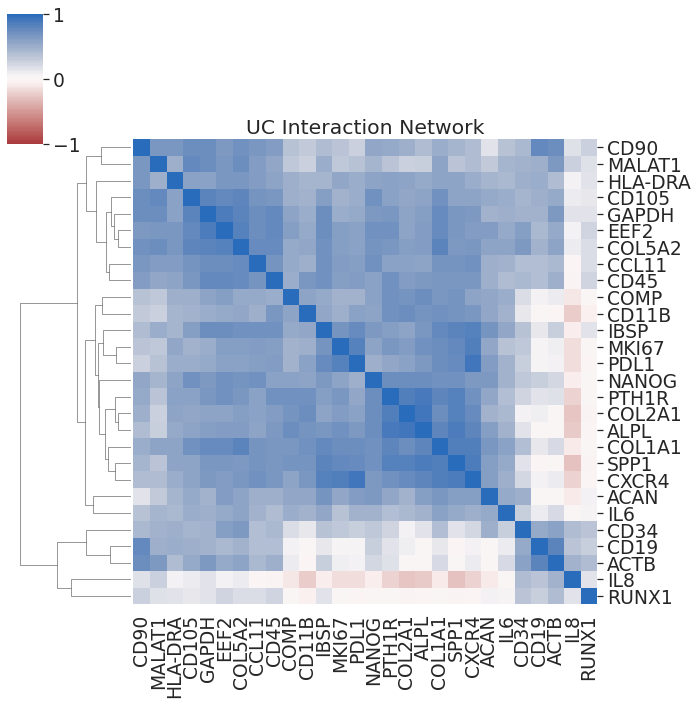

In [16]:
ax = sns.clustermap(ucint, vmin=-1, vmax=1, cmap=palette, xticklabels=fet, yticklabels=fet)
ax.ax_heatmap.set_title('UC '+description)
# ax.fig.suptitle('UC '+description)
ax.ax_col_dendrogram.set_visible(False)
ax.savefig("UCinteractions.png") 

....................................................................................................................................................
Made bm figure!
.........................................................................................................................................................
Made uc figure!


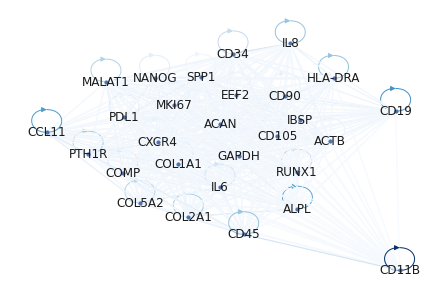

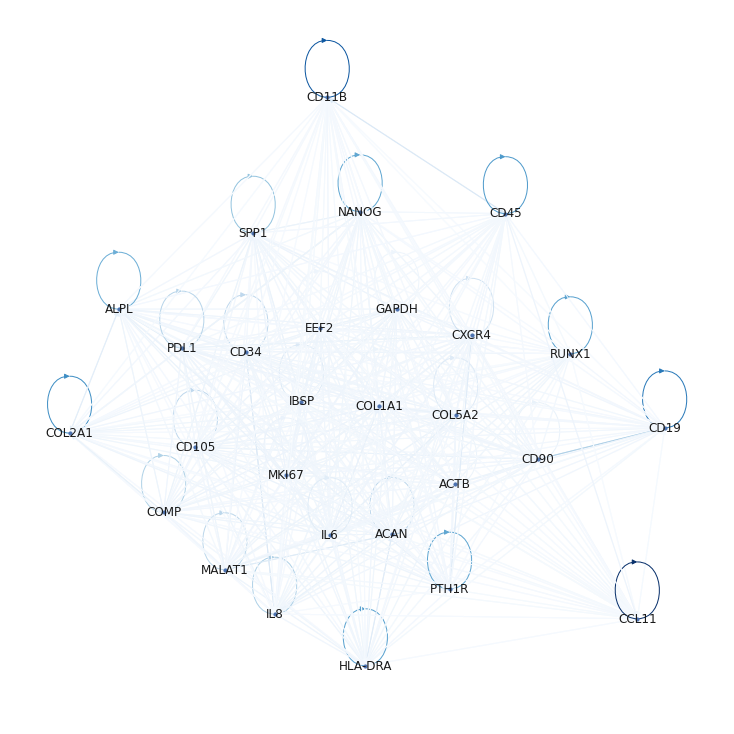

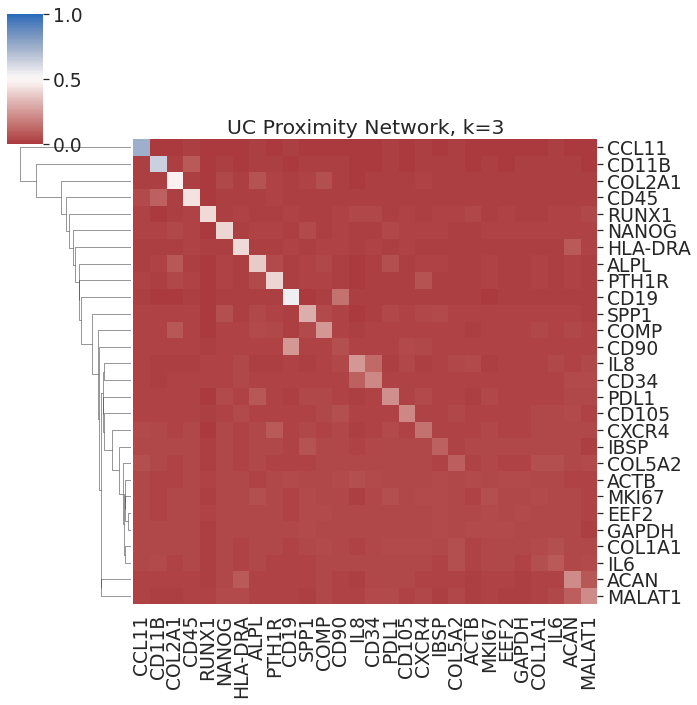

In [19]:
description = 'Proximity Network'
n_neighbors = 3


for which in ['bm','uc']:
    files = [which+'_28_gene_rna_positions/28_gene_rna_positions/'+i for i in os.listdir(which+'_28_gene_rna_positions/28_gene_rna_positions/')]
    genes = [i.replace(',','') for i in 'CD19,CD90,HLA-DRA,ACAN,CD105,IL8,CD34,ACTB,MALAT1,RUNX1,IBSP,COMP,EEF2,SPP1,COL2A1,GAPDH,NANOG,ALPL,MKI67,PDL1,PTH1R,COL1A1,CXCR4,COL5A2,IL6,CCL11,CD11B,CD45'.split(',')]

    counts = np.zeros((len(genes),len(genes)))
    for file in files:
        print('.',end='')
        with open(file, 'rb') as f:
            data = pickle.load(f)
            g = [i for i in range(len(genes)) for _ in data[genes[i]]]
            l = np.array([j for i in genes for j in data[i]])
            clf = KNeighborsClassifier()
            clf.fit(l, g)
            neighbors = [[g[i] for i in j] for j in clf.kneighbors(l,  n_neighbors=n_neighbors+1)[1]]
            # print(neighbors)
            for i in neighbors:
                for k in i[1:]:
                    counts[i[0],k] += 1
    # for i in range(len(genes)):
    #     # ignore self interactions if you want
    #     counts[i,i] = 1/np.sum(counts)
    mat = np.zeros_like(counts)
    for i in range(len(genes)):
        # scale a count by the number of times the gene appears
        # so if a gene is more common, it appearing nearby shows less evidence that they are interacting
        mat[:,i] = counts[:,i]/np.sum(counts[i,:])
    for i in range(len(genes)):
        # normalize for each gene
        mat[i,:] = mat[i,:]/np.sum(mat[i,:])
    
    plt.clf() 
    G = nx.DiGraph()
    for i in range(len(mat)):
        for j in range(len(mat)):
            G.add_edge(genes[i],genes[j],weight=mat[i][j])
    edges,weights = zip(*nx.get_edge_attributes(G,'weight').items())
    pos = nx.spring_layout(G)
    nx.draw(G, pos, node_color='b', edgelist=edges, with_labels=True, edge_color=weights, width=1.0, node_size=10, edge_cmap=plt.cm.Blues)
    plt.savefig(which.upper()+'proximityGraph.png')
    
    mat = pd.DataFrame(mat,columns=genes)
    link = linkage(mat)
    ax = sns.clustermap(mat, vmin=0, vmax=1, cmap=palette, xticklabels=genes, yticklabels=genes, row_linkage=link, col_linkage=link)
    ax.ax_heatmap.set_title(which.upper()+' '+description+f', k={n_neighbors}')
    ax.ax_col_dendrogram.set_visible(False)
    ax.savefig(which.upper()+'proximity.png')
    print('\nMade '+which+' figure!')